# Stage 2: Critic Pretraining

Load actor Stage 1 (LoRA r=16), them critic head, freeze actor.
Train critic voi sampled actions de match PPO. Reward None=0.0 (consistent voi Stage 3).

In [1]:
!pip install -q torchao --upgrade
!pip install -q --upgrade transformers peft accelerate sentencepiece
!pip install -q torch pyvi pandas matplotlib scikit-learn

In [2]:
import json, os, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pyvi import ViTokenizer
from sklearn.metrics import classification_report, f1_score
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
import torch.nn.functional as F
from torch.distributions import Categorical

In [4]:
SEED = 42
MODEL_NAME = "vinai/phobert-base"
MAX_LEN = 256
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ASPECT_COLS = [
    "FACILITIES#CLEANLINESS","FACILITIES#COMFORT","FACILITIES#DESIGN&FEATURES","FACILITIES#GENERAL",
    "FACILITIES#MISCELLANEOUS","FACILITIES#PRICES","FACILITIES#QUALITY","FOOD&DRINKS#MISCELLANEOUS",
    "FOOD&DRINKS#PRICES","FOOD&DRINKS#QUALITY","FOOD&DRINKS#STYLE&OPTIONS","HOTEL#CLEANLINESS",
    "HOTEL#COMFORT","HOTEL#DESIGN&FEATURES","HOTEL#GENERAL","HOTEL#MISCELLANEOUS","HOTEL#PRICES",
    "HOTEL#QUALITY","LOCATION#GENERAL","ROOMS#CLEANLINESS","ROOMS#COMFORT","ROOMS#DESIGN&FEATURES",
    "ROOMS#GENERAL","ROOMS#MISCELLANEOUS","ROOMS#PRICES","ROOMS#QUALITY","ROOM_AMENITIES#CLEANLINESS",
    "ROOM_AMENITIES#COMFORT","ROOM_AMENITIES#DESIGN&FEATURES","ROOM_AMENITIES#GENERAL",
    "ROOM_AMENITIES#MISCELLANEOUS","ROOM_AMENITIES#PRICES","ROOM_AMENITIES#QUALITY","SERVICE#GENERAL",
]
LABEL_NAMES = ["None", "Positive", "Negative", "Neutral"]
N_POLARITIES = len(LABEL_NAMES)
N_ASPECTS    = len(ASPECT_COLS)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print(f"Device: {DEVICE}")

Device: cuda


In [5]:
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR  = Path("/content/drive/MyDrive/task2_dataset")
SAVE_PATH = Path("/content/drive/MyDrive/ABSA_Task2")
SAVE_PATH.mkdir(parents=True, exist_ok=True)
print(f"DATA_DIR : {DATA_DIR}")
print(f"SAVE_PATH: {SAVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR : /content/drive/MyDrive/task2_dataset
SAVE_PATH: /content/drive/MyDrive/ABSA_Task2


In [6]:
# LoRA r=16 target query+key+value (capacity lon hon r=8/qv) - bat buoc giong nhau
# giua Stage 1, 2, 3 vi checkpoint phai compatible.
LORA_R           = 16
LORA_ALPHA       = 32
LORA_TARGETS     = ["query", "key", "value"]
LORA_DROPOUT     = 0.1
HEAD_DROPOUT     = 0.2

def build_lora_backbone():
    phobert = AutoModel.from_pretrained(MODEL_NAME)
    return get_peft_model(phobert, LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, target_modules=LORA_TARGETS,
        lora_dropout=LORA_DROPOUT, bias="none"))

class PhoBertACSA_LoRA(nn.Module):
    def __init__(self):
        super().__init__()
        self.phobert    = build_lora_backbone()
        self.dropout    = nn.Dropout(HEAD_DROPOUT)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS * N_POLARITIES)
    def forward(self, input_ids, attention_mask):
        out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.last_hidden_state[:, 0, :])
        return self.classifier(pooled).view(-1, N_ASPECTS, N_POLARITIES)

class PhoBertACSA_ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.phobert    = build_lora_backbone()
        self.dropout    = nn.Dropout(HEAD_DROPOUT)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS * N_POLARITIES)
        self.critic     = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS)
    def forward(self, input_ids, attention_mask):
        out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.last_hidden_state[:, 0, :])
        logits = self.classifier(pooled).view(-1, N_ASPECTS, N_POLARITIES)
        values = self.critic(pooled)
        return logits, values

In [7]:
def compute_step_rewards(actions, labels):
    r = torch.full(labels.shape, -1.0, device=labels.device)
    ok = actions == labels
    r[ok & ((labels==2)|(labels==3))] = 2.0   # Negative, Neutral
    r[ok & (labels==1)] = 1.0                  # Positive
    r[ok & (labels==0)] = 0.0                  # None - khong reward
    return r

In [8]:
class ABSADataset(Dataset):
    def __init__(self, df, tokenizer):
        texts = df["Review"].fillna("").astype(str).tolist()
        tokenized = [ViTokenizer.tokenize(t.lower()) for t in texts]
        self.encodings = tokenizer(tokenized, truncation=True, add_special_tokens=True,
                                   max_length=MAX_LEN, padding="max_length")
        self.labels = df[ASPECT_COLS].astype("int64").to_numpy()
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i], dtype=torch.long) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

def make_loader(df, tokenizer, shuffle=False):
    return DataLoader(ABSADataset(df, tokenizer), batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=0, pin_memory=True)

def compute_metrics(y_true, y_pred):
    ft, fp = y_true.reshape(-1), y_pred.reshape(-1)
    m = {
        "flat_macro_f1": f1_score(ft, fp, labels=list(range(N_POLARITIES)), average="macro", zero_division=0),
        "exact_match":   float(np.mean(np.all(y_true == y_pred, axis=1))),
    }
    mask = ft != 0
    m["non_none_macro_f1"]   = f1_score(ft[mask], fp[mask], labels=[1,2,3], average="macro", zero_division=0) if mask.any() else 0.0
    m["per_aspect_macro_f1"] = float(np.mean([
        f1_score(y_true[:,a], y_pred[:,a], labels=list(range(N_POLARITIES)), average="macro", zero_division=0)
        for a in range(y_true.shape[1])]))
    return m

@torch.no_grad()
def evaluate_model(model, loader, criterion=None):
    model.eval()
    all_labels, all_preds, total_loss = [], [], 0.0
    for batch in loader:
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        out    = model(ids, mask)
        logits = out[0] if isinstance(out, tuple) else out
        if criterion:
            total_loss += criterion(logits.reshape(-1, N_POLARITIES), labels.reshape(-1)).item()
        all_labels.append(labels.cpu().numpy())
        all_preds.append(logits.argmax(-1).cpu().numpy())
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    m = compute_metrics(y_true, y_pred)
    if criterion:
        m["loss"] = total_loss / max(len(loader), 1)
    m["y_true"] = y_true; m["y_pred"] = y_pred
    return m

def print_metrics(prefix, m):
    keys = ["loss","flat_macro_f1","non_none_macro_f1","per_aspect_macro_f1","exact_match"]
    parts = [f"{k}: {m[k]:.4f}" for k in keys if k in m]
    print(f"{prefix} | " + " | ".join(parts))

def sample_actions(logits):
    dist = Categorical(logits=logits)
    a = dist.sample()
    return a, dist.log_prob(a)

def kl_divergence(logits, ref_logits):
    lp = F.log_softmax(logits,     dim=-1)
    lq = F.log_softmax(ref_logits, dim=-1)
    return (lp.exp() * (lp - lq)).sum(dim=-1)

In [9]:
tokenizer    = AutoTokenizer.from_pretrained(MODEL_NAME)
train_df     = pd.read_csv(DATA_DIR / "1-VLSP2018-SA-Hotel-train.csv")
dev_df       = pd.read_csv(DATA_DIR / "2-VLSP2018-SA-Hotel-dev.csv")
train_loader = make_loader(train_df, tokenizer, shuffle=True)
dev_loader   = make_loader(dev_df,   tokenizer)
print(f"train {len(train_df)} | dev {len(dev_df)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train 3000 | dev 2000


In [10]:
import shutil

def save_ckpt(state_dict, drive_path):
    """Save xuong /content/ truoc roi copy sang Drive de tranh iostream error."""
    tmp = Path("/content") / drive_path.name
    torch.save(state_dict, tmp)
    shutil.copy(tmp, drive_path)
    tmp.unlink()
    return drive_path

def evaluate_critic(model, loader, criterion):
    model.eval(); total = 0.0
    with torch.no_grad():
        for batch in loader:
            ids    = batch["input_ids"].to(DEVICE)
            mask   = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            logits, values = model(ids, mask)
            actions, _ = sample_actions(logits)
            total += criterion(values, compute_step_rewards(actions, labels)).item()
    return total / max(len(loader), 1)

EPOCHS_CRITIC = 3
LR_CRITIC     = 1e-4

model = PhoBertACSA_ActorCritic().to(DEVICE)
stage1_ckpt = SAVE_PATH / "best_model_sft.bin"
if not stage1_ckpt.exists():
    raise FileNotFoundError(f"Chua co Stage 1 checkpoint: {stage1_ckpt}")

missing, unexpected = model.load_state_dict(torch.load(stage1_ckpt, map_location=DEVICE), strict=False)
if [k for k in missing if not k.startswith("critic.")] or unexpected:
    raise RuntimeError(f"Checkpoint mismatch. Missing: {missing} | Unexpected: {unexpected}")
print("Loaded Stage 1 actor; critic se train moi.")

for name, p in model.named_parameters():
    p.requires_grad = name.startswith("critic.")
trainable = [p for p in model.parameters() if p.requires_grad]
print(f"Trainable critic params: {sum(p.numel() for p in trainable):,}")

criterion_mse = nn.MSELoss()
optimizer = AdamW(trainable, lr=LR_CRITIC)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.06 * len(train_loader) * EPOCHS_CRITIC)),
    num_training_steps=len(train_loader) * EPOCHS_CRITIC)

history, best_val, best_ckpt = [], float("inf"), SAVE_PATH / "actor_critic_pretrained.bin"

for epoch in range(1, EPOCHS_CRITIC + 1):
    model.eval(); total_loss = 0.0
    for batch in train_loader:
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits, values = model(ids, mask)
        with torch.no_grad():
            actions, _ = sample_actions(logits)
            target     = compute_step_rewards(actions, labels)
        loss = criterion_mse(values, target)
        loss.backward()
        nn.utils.clip_grad_norm_(trainable, 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)
    val_loss   = evaluate_critic(model, dev_loader, criterion_mse)
    history.append({"epoch": epoch, "train_mse": train_loss, "val_mse": val_loss})
    print(f"Epoch {epoch}/{EPOCHS_CRITIC} | train_mse {train_loss:.4f} | val_mse {val_loss:.4f}")
    if val_loss < best_val:
        best_val = val_loss
        save_ckpt(model.state_dict(), best_ckpt)
        print(f"  -> saved {best_ckpt}")

pd.DataFrame(history).to_csv(SAVE_PATH / "stage2_history.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded Stage 1 actor; critic se train moi.
Trainable critic params: 26,146
Epoch 1/3 | train_mse 0.4605 | val_mse 0.3652
  -> saved /content/drive/MyDrive/ABSA_Task2/actor_critic_pretrained.bin
Epoch 2/3 | train_mse 0.3930 | val_mse 0.3563
  -> saved /content/drive/MyDrive/ABSA_Task2/actor_critic_pretrained.bin
Epoch 3/3 | train_mse 0.3883 | val_mse 0.3550
  -> saved /content/drive/MyDrive/ABSA_Task2/actor_critic_pretrained.bin


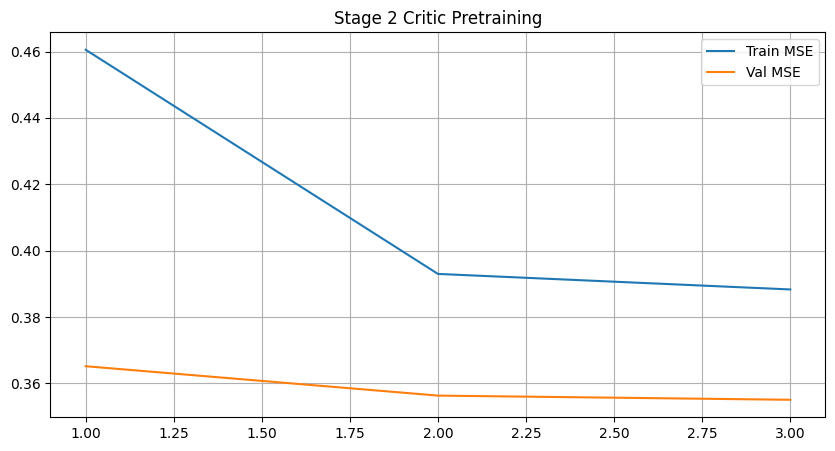

In [11]:
hist = pd.read_csv(SAVE_PATH / "stage2_history.csv")
plt.figure(figsize=(10,5))
plt.plot(hist["epoch"], hist["train_mse"], label="Train MSE")
plt.plot(hist["epoch"], hist["val_mse"],   label="Val MSE")
plt.title("Stage 2 Critic Pretraining"); plt.legend(); plt.grid(True); plt.show()